# ME 280 Homework 2

I am going to start off by importing the necessary packages as opposed to importing them over and over again for every cell which I used to do.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import ultralytics
import json
import os

> Image Enhancement: With the given sudoku image in file (sudoku-original.png), using both CLAHE and Histogram Equalization methods. Compare the image before and after, for both methods, as well as the distribution of pixel values.

I used OpenCV for 3 years in highschool for the robotics team, but that was in Java. It will be interesting to see how the API pans out in a different languages. However, as it turns out, dealing with live camera feed is a lot different in Java as opposed to still images in Python so only the most basic knowledge of mine transferred over.

So I used http://opencv24-python-tutorials.readthedocs.io/ to its fullest extent and patched together a lot of tutorials.


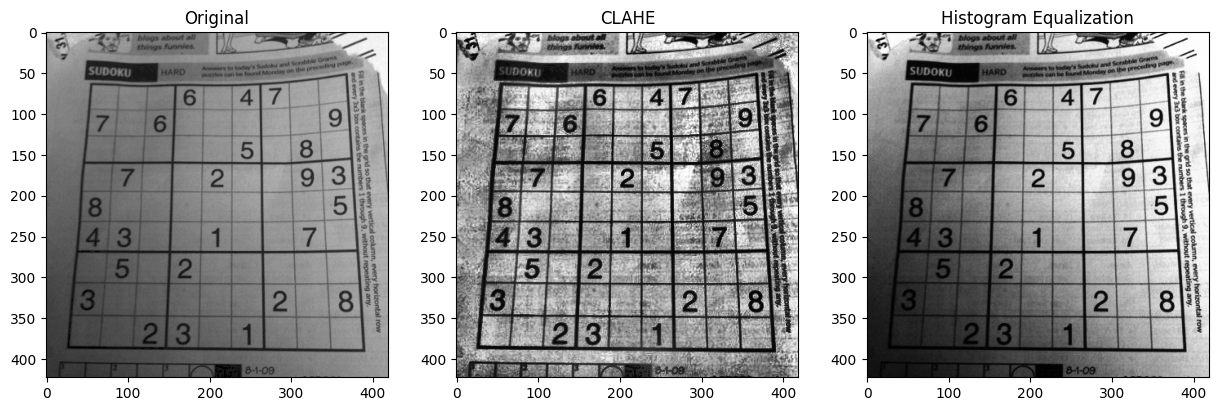

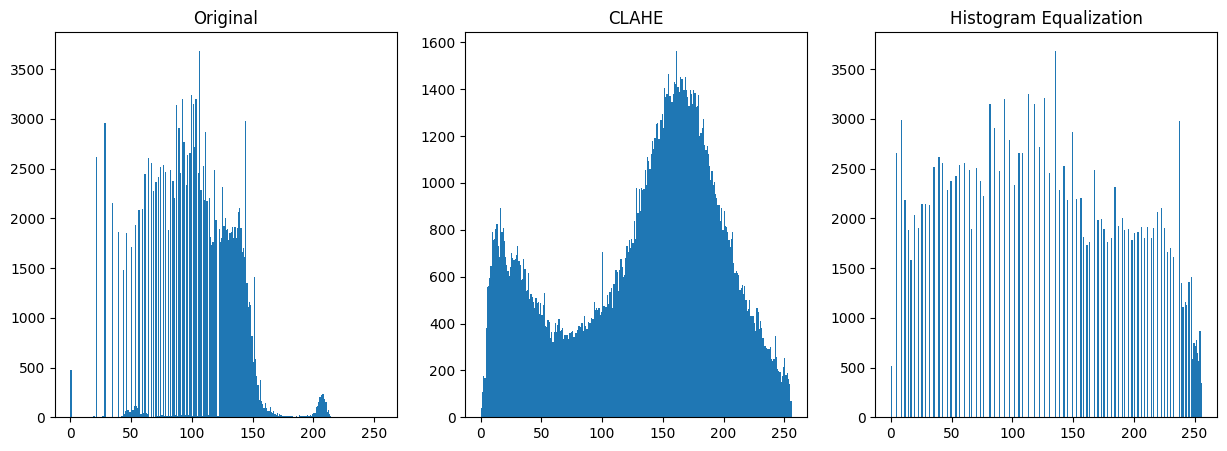

In [ ]:
# Paths are relative to the current file in Python, or at least this is the case in Jupyter
# notebooks which tripped me up since I use Node.JS a lot and that's working directory relative.
# Anyway, cv2 has imread which makes reading images trivial. the cv2.IMREAD_GRAYSCALE flag
# makes the image grayscale.
sudoku_original = cv2.imread(
    "../../perception/sudoku-original.png", cv2.IMREAD_GRAYSCALE
)

# I am not 100% sure what the value of clahe represents, perhaps it is a configuration object?
# Regardless, it acts like a class in the sense that after creating an instance of it, you can
# call methods on it like the apply function that we see below which accepts a single image in
# the form of a numpy array.
clahe = cv2.createCLAHE()
sudoku_clahe = clahe.apply(sudoku_original)

# Equalizing is even more trivial since cv2 has a built-in function for it.
sudoku_histogram_equalized = cv2.equalizeHist(sudoku_original)

# Displaying the images is far more involved than I first anticipated. I didn't want to write
# to disk and just show the images in the notebook so I use matplotlib's imshow function. But
# before I use that function, I declare a figure and an axes object. I chose a size of 5 for
# the individual images, of which I have 3, so I went with an overall size of 15x5.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# These functions are pretty straight forward. I did find it interesting that I have to set
# cmap explicitly to gray, otherwise it comes out all colorful for some reason? And of course
# the other methods are for setting the titles.
axes[0].imshow(sudoku_original, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(sudoku_clahe, cmap="gray")
axes[1].set_title("CLAHE")
axes[2].imshow(sudoku_histogram_equalized, cmap="gray")
axes[2].set_title("Histogram Equalization")

# Show the plot.
plt.show()

# Another plot, but this time for the histograms. Same deal as before for the disk situation and
# the sizes. However, this time I use the hist function instead of imshow which accepts bins
# which, to the best of my understanding, controls the resolution of the histogram while the range
# is self explanatory.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(sudoku_original.ravel(), bins=256, range=(0, 256))
axes[0].set_title("Original")
axes[1].hist(sudoku_clahe.ravel(), bins=256, range=(0, 256))
axes[1].set_title("CLAHE")
axes[2].hist(sudoku_histogram_equalized.ravel(), bins=256, range=(0, 256))
axes[2].set_title("Histogram Equalization")

plt.show()

The results shouldn't be too surprising since CLAHE does not concern itself with the entire image at once, rather choosing to operate in a small neighborhood, so we end up with a histogram that makes large strides towards an image with more contrast and little gaps in the brightness distribution which still somewhat resembling the original distribution. The image shows a lot more texture due to this which is kind of counter-intuitive as in my histogram equalization is the more aggressive method,

Histogram equalization on the hand, like I noted, appears to be a lot more aggressive, judging solely by the distribution, but the produced image is a lot closer to the original. I suppose this shouldn't be surprising since this method concerns itself with the composition of the entire image at once, allowing it to make more of a softer change.

Onto edge detection!


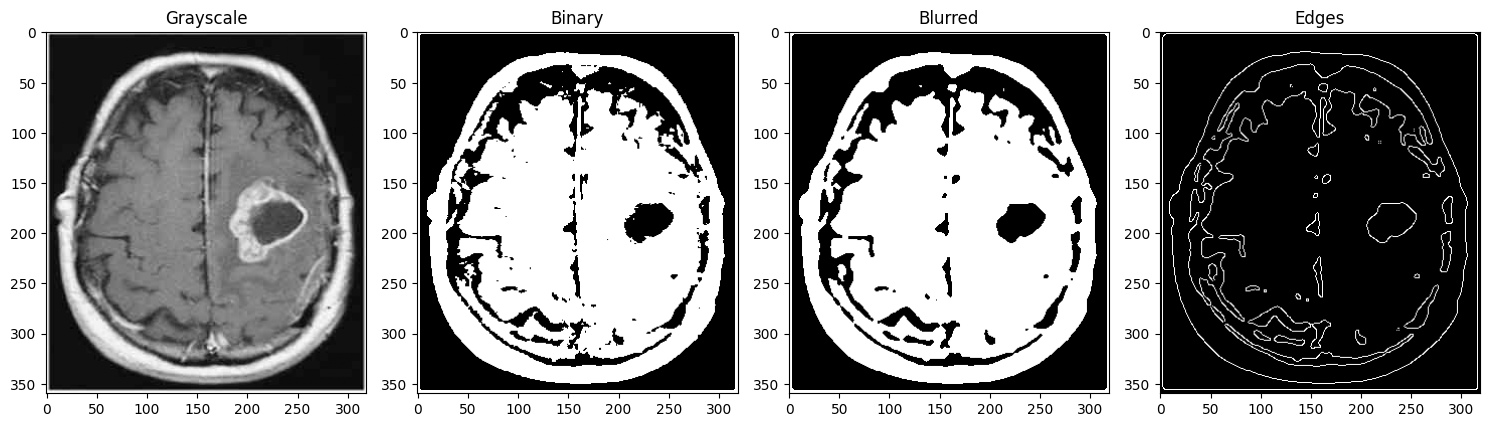

In [ ]:
# The same deal as before, reading an image with this library is trivial.
tumor = cv2.imread("../../perception/image_tumor.jpg")

# To make the image grayscale, the cvtColor method accepts the original image,
# and a flag for the desired format, in this case cv2.COLOR_BGR2GRAY.
gray = cv2.cvtColor(tumor, cv2.COLOR_BGR2GRAY)

# Thresholds are also made easy due to the library. Here, I chose 0 and 255
# against the recommendation from the docs to use like 50 and 200 because in
# my case it seems to work just the same, but using numbers that are familiar
# to me.
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)

# There's a median blur built into the library as well. I chose 5px, just like
# the online example since that seemed to retain the most information while
# not going overboard.
blurred = cv2.medianBlur(binary, 5)

# Edges uses canny (which has a capital C for some reason?). Since the thresholds
# are at 0 and 255, I went with the same here, though for more gradients, you'd
# want to experiment with different values.
edges = cv2.Canny(blurred, 0, 255)

# Same deal as before for the figure and axes.
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale")
axes[1].imshow(binary, cmap="gray")
axes[1].set_title("Binary")
axes[2].imshow(blurred, cmap="gray")
axes[2].set_title("Blurred")
axes[3].imshow(edges, cmap="gray")
axes[3].set_title("Edges")

plt.tight_layout()
plt.show()

Okay, this is cool. No matter how many times I use these methods, wether its highschool robotics collision detection or edge detection for an assignment, these techniques always have a charm due to how intuitive they are. It's of course the programming which stops most from exploring these methods.

Regardless, let's talk about the image, but in a backwards order. To detect an edge, its easiest to look for edges of high gradients which is exactly what happens between images 3 and 4 where the sudden shift from 0 to 255 is easy to pick up as an edge and is rendered as lines in image 4.

As for the transformation from images 2 to 3, that's purely to address the noise of the real world that seeps its way into the image. With burring, you end up with cleaner edges to work with, without jagged edges. And finally, or should I say, first and foremost, image 1 to image 2 deals will crunching the data into a binary system. It better be either 0 or 255 for the ease of computing.

Onto custom blurring!


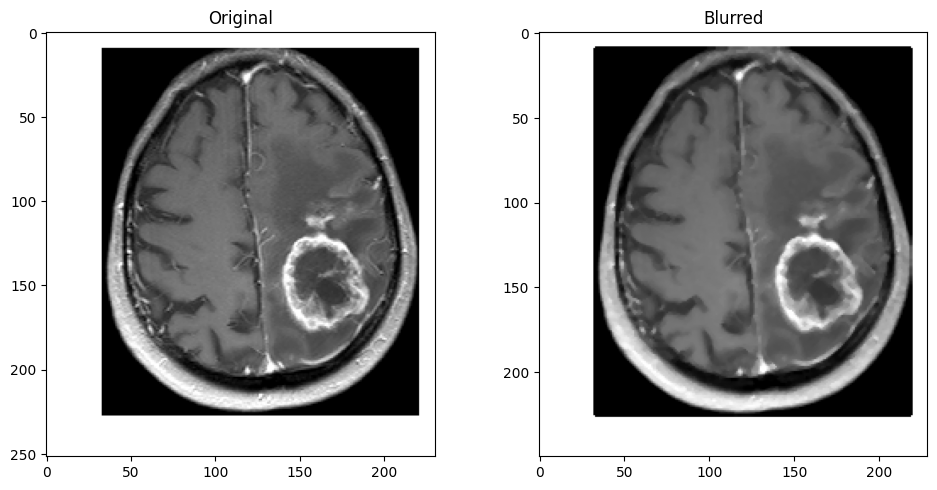

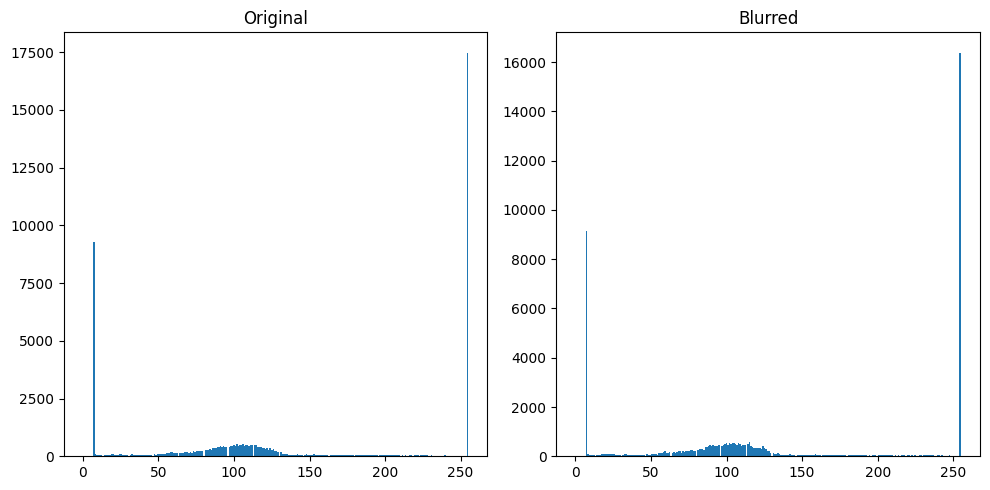

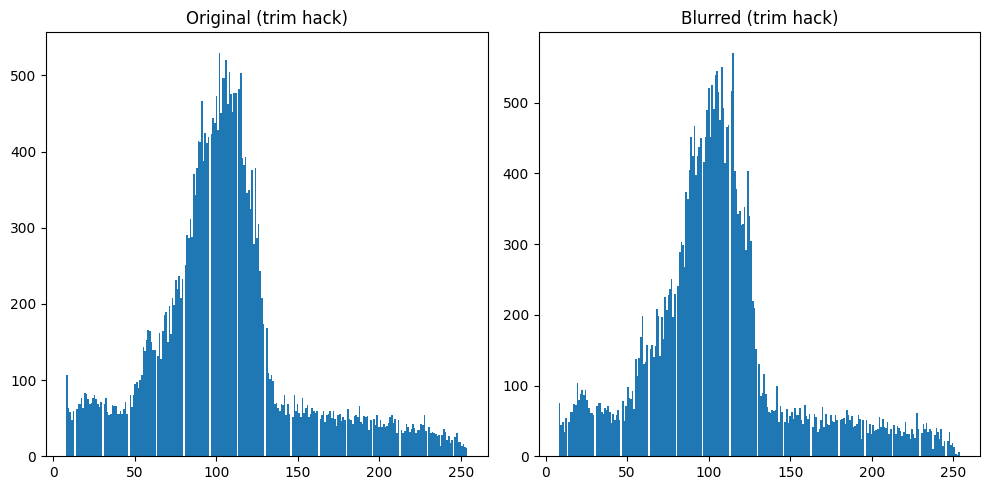

In [5]:
# Read the image and convert to grayscale.
tumor = cv2.imread("../../perception/tumor-image.png")
gray = cv2.cvtColor(tumor, cv2.COLOR_BGR2GRAY)


# The docs recommends for custom kernels to just manually write the iterators
# to my surprise. I expected a fancy convolution function that smeared your
# kernel over the image, but nope!
def custom_blur(image):

    # First I obtain the dimensions of the image.
    height, width = image.shape

    # But then I trim the edges off by 2px.
    result = np.zeros((height - 2, width - 2))

    # Two nested loops going between the bounds of the image with uv coords.
    for u in range(1, height - 1):
        for v in range(1, width - 1):

            # The question asks for a 3x3 kernel, so I didn't bother
            # generalizing this into another set of loop, just used
            # the median function from numpy.
            patch = image[u - 1 : u + 2, v - 1 : v + 2]

            # Overwrite the pixel with the median value.
            result[u - 1, v - 1] = np.median(patch)

    return result


custom_blurred = custom_blur(gray)

# Figure and axis this time is 10x5 since there's just two images.
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(custom_blurred, cmap="gray")
axes[1].set_title("Blurred")

plt.tight_layout()
plt.show()

# Same 10x5 figure and axes. But this produces a histogram that's
# practically useless for analysis since everything is flat in
# contrast to the spikes on either side. So, I plot these
# again later with a different range.
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].hist(gray.ravel(), bins=256, range=(0, 255))
axes[0].set_title("Original")
axes[1].hist(custom_blurred.ravel(), bins=256, range=(0, 255))
axes[1].set_title("Blurred")

plt.tight_layout()
plt.show()


# And this is my implementation for the trimmed range.
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# I used words like "hack" to catch attention for future readers
# to let them know this isn't really meant to be here.
range_hack = (8, 254)
bins_hack = range_hack[1] - range_hack[0] + 1

axes[0].hist(gray.ravel(), bins=bins_hack, range=range_hack)
axes[0].set_title("Original (trim hack)")
axes[1].hist(custom_blurred.ravel(), bins=bins_hack, range=range_hack)
axes[1].set_title("Blurred (trim hack)")

plt.tight_layout()
plt.show()

If you are wondering where there are two sets of graphs, please refer to my comments in the code. But, in a nutshell, I find the first set of graphs to be useless with the spikes.

Regardless, it was sort of hard to tell if my blurring function was even working because it's only 3px. However, note how fine lines and seams of the brain disappear after the blur and how everything gets a bit fuzzier.

And as for the histogram, I was stumped as to why they looked practically the same but then it dawned on me that all a blur really does is make all bars progressively of similar heights as you blur more and more. But since its only blurred for 3px, it's not really that noticeable.

Onto AIs!


In [ ]:
# The YOLO API is a little too verbose for the purposes for this assignment
# so I made a simple function to train a YOLO model.
def train(name: str, imgsz: int, pretrained: bool):
    return YOLO(f"{name}.yaml").train(
        data="../../perception/data.yaml",
        epochs=25,
        imgsz=imgsz,
        batch=2,
        pretrained=pretrained,
    )


# And a simple function to postmortem the results. I declared these functions in this individual
# block so that I can isolate batches of trainings from both each other and these helper functions.
def postmortem(report, name: str):
    print(f"P ({name}) =", report.results_dict["metrics/precision(B)"])
    print(f"R ({name}) =", report.results_dict["metrics/recall(B)"])
    print(f"mAP@0.5 ({name}) =", report.results_dict["metrics/mAP50(B)"], end="\n\n")


# Another method for predicting with YOLO, but placing the images side by side.
def predict_many(dirs: list[str], titles: list[str]):

    length = len(dirs)

    # The size of course is now variable, but still a multiple of 5.
    fig, axes = plt.subplots(1, length, figsize=(length * 5, 5))

    for i in range(length):
        dir = dirs[i]
        title = titles[i]

        # The weights are relative to the current file, so I use ./.
        model = YOLO(f"./runs/detect/{dir}/weights/best.pt")
        prediction = model.predict("../../perception/bus.jpg", verbose=False)

        # My humans looked blue, and as it turns out, YOLO outputs in BGR... for some reason?
        # Reversing it is actually easy in Python, reminiscent of MATLAB.
        bgr = prediction[0].plot()
        rgb = bgr[:, :, ::-1]

        axes[i].imshow(rgb)
        axes[i].set_title(title)

    plt.tight_layout()
    plt.show()

In [6]:
report_nano = train("yolo11n", 64, False)
report_small = train("yolo11s", 64, False)
report_medium = train("yolo11m", 64, False)
report_large = train("yolo11l", 64, False)

Ultralytics 8.3.221 🚀 Python-3.10.12 torch-2.9.0+cu128 CUDA:0 (GRID A100X-10C, 10236MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../perception/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

In [7]:
postmortem(report_nano, "nano")
postmortem(report_small, "small")
postmortem(report_medium, "medium")
postmortem(report_large, "large")

P (nano) = 0.22347881974425163
R (nano) = 0.06917537377870385
mAP@0.5 (nano) = 0.04893739485764279

P (small) = 0.2786021268742506
R (small) = 0.08109431664769569
mAP@0.5 (small) = 0.05940836827807052

P (medium) = 0.25972516100912807
R (medium) = 0.08641249336646006
mAP@0.5 (medium) = 0.05979845130965619

P (large) = 0.22805742316954752
R (large) = 0.08166911839781575
mAP@0.5 (large) = 0.05837376741298166



Even before I look at the numbers, anticipate precision and recall to simply go just because of the fact that the models are bigger, while the mean average prevision hovers at about the same value.

Now that I am looking at the numbers, I must say, I am surprised. P hikes from nano to small, but then takes a hit when going to medium and large for some reason? I cannot think of a single reason why this would be the case? Perhaps a P of 0.28 is already a very good value so they all asymptote to the same value?

As for the R, it's a similar story. The value hikes from 0.069 to 0.086 from nano to medium, but then takes a massive hit in large. Perhaps this is happening because of the fact we only use 25 epochs which is might be fine for nano but too little to hone in on all the neurons of the larger models. The same is true for mAP@0.5 which dips from medium.


In [8]:
report_nano_128 = train("yolo11n", 128, False)
report_nano_256 = train("yolo11n", 256, False)
report_nano_512 = train("yolo11n", 512, False)

Ultralytics 8.3.221 🚀 Python-3.10.12 torch-2.9.0+cu128 CUDA:0 (GRID A100X-10C, 10236MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../perception/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, 

In [9]:
postmortem(report_nano, "nano 64px")
postmortem(report_nano_128, "nano 128px")
postmortem(report_nano_256, "nano 256px")
postmortem(report_nano_512, "nano 512px")

P (nano 64px) = 0.22347881974425163
R (nano 64px) = 0.06917537377870385
mAP@0.5 (nano 64px) = 0.04893739485764279

P (nano 128px) = 0.20641078068910185
R (nano 128px) = 0.10788877594021377
mAP@0.5 (nano 128px) = 0.06315802884359502

P (nano 256px) = 0.3308291380545722
R (nano 256px) = 0.19436082927757756
mAP@0.5 (nano 256px) = 0.15368465078427931

P (nano 512px) = 0.4918226009826939
R (nano 512px) = 0.3223256334221119
mAP@0.5 (nano 512px) = 0.33252710460314505



I just realized how small 64px is. I looked up an image that small and it's even hard for me to see what's what. No wonder the models were so bad. I anticipate a hike in P, R, and mAP, with as asymptote as we reach 512px because there's only so much you can glean from an image that big compared to 256px.

Looking at the numbers, what I said was absolutely wrong. There seems to be an exponential increase in mAP and R, and somewhat of a linear on for P. I suppose this makes sense since we are quadrupling the number of pixels each level, not just going up linearly. But still, I anticipate 1024px to perform barely better than 512px, but that's something that we do not test for.


In [10]:
report_nano_pretrained = train("yolo11n", 64, True)
report_medium_pretrained = train("yolo11m", 64, True)
report_large_pretrained = train("yolo11l", 64, True)

Ultralytics 8.3.221 🚀 Python-3.10.12 torch-2.9.0+cu128 CUDA:0 (GRID A100X-10C, 10236MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../perception/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

In [11]:
postmortem(report_nano, "nano")
postmortem(report_medium, "medium")
postmortem(report_large, "large")

postmortem(report_nano_pretrained, "nano pretrained")
postmortem(report_medium_pretrained, "medium pretrained")
postmortem(report_large_pretrained, "large pretrained")

P (nano) = 0.22347881974425163
R (nano) = 0.06917537377870385
mAP@0.5 (nano) = 0.04893739485764279

P (medium) = 0.25972516100912807
R (medium) = 0.08641249336646006
mAP@0.5 (medium) = 0.05979845130965619

P (large) = 0.22805742316954752
R (large) = 0.08166911839781575
mAP@0.5 (large) = 0.05837376741298166

P (nano pretrained) = 0.22347881974425163
R (nano pretrained) = 0.06917537377870385
mAP@0.5 (nano pretrained) = 0.04893739485764279

P (medium pretrained) = 0.25972516100912807
R (medium pretrained) = 0.08641249336646006
mAP@0.5 (medium pretrained) = 0.05979845130965619

P (large pretrained) = 0.22805742316954752
R (large pretrained) = 0.08166911839781575
mAP@0.5 (large pretrained) = 0.05837376741298166



As for the pretraining, I expect very little different between pre-trained and no pre-trained models. I surely can't be wrong about these numbers 3 times in a row right?

I am please to announce to you that, I, for once, this assignment have been correct in predicting how the models will perform. Pre-training makes sense if you're dealing with an LLM where the bulk of new tasks also involves mostly spitting out words. But for YOLO, it's got thousands of image tags to work with, where "Face" and "Person" make up a very small portion, so it shouldn't be surprising to see the pre-trained weights get completely overwritten by the new weights, designed solely for the new task.


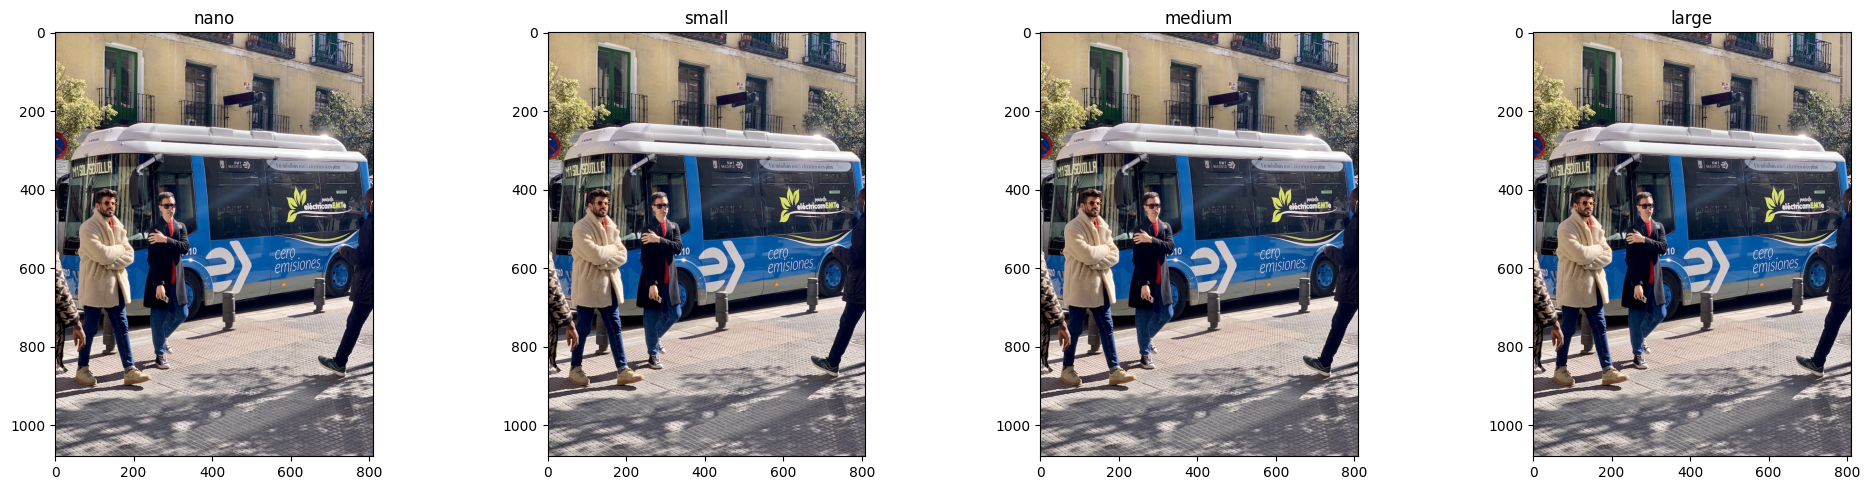

In [18]:
predict_many(
    ["train", "train2", "train3", "train4"], ["nano", "small", "medium", "large"]
)

I must say I am disappointed. But perhaps I shouldn't since the values for R, which represents how often the AI does not miss, were all ridiculously low. I have spent some time thinking about what I could've done wrong but I cannot come up with any other solution than just retraining it, for which I do not have the time anymore since it's Oct 25th already. Perhaps a hike in epochs would help? Sorry, prof.!


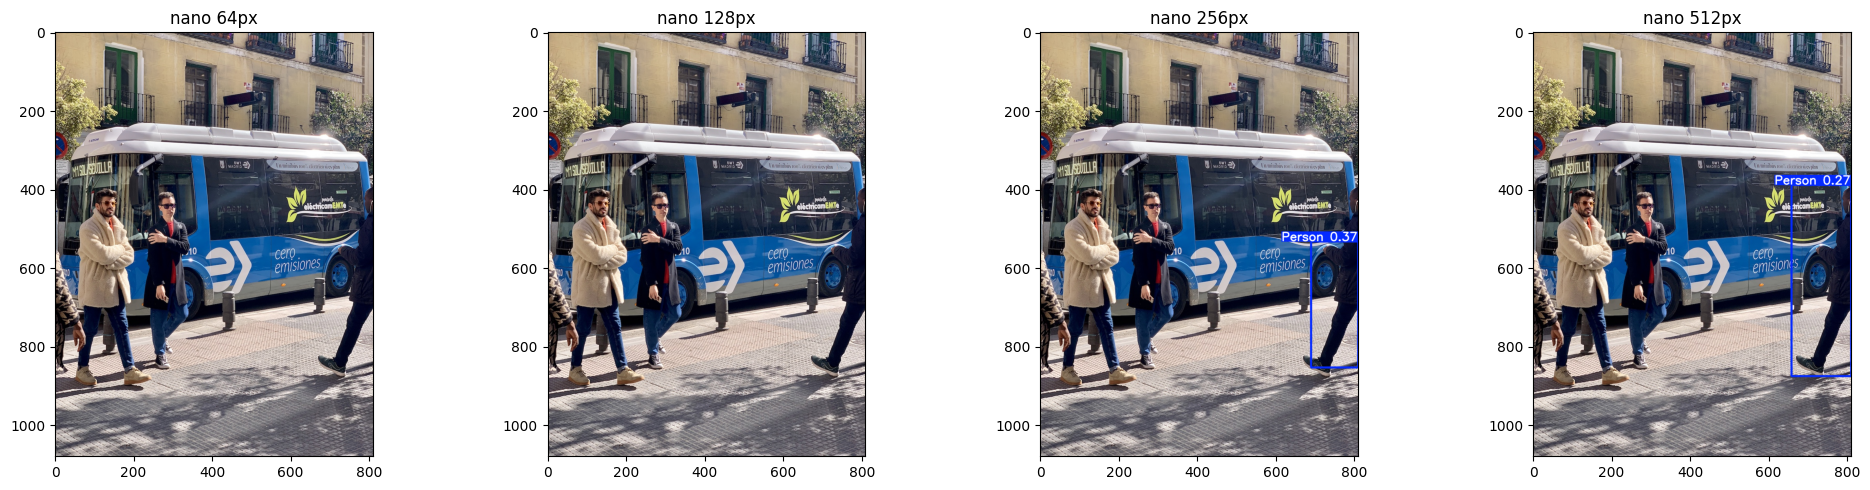

In [19]:
predict_many(
    ["train", "train4", "train5", "train6"],
    ["nano 64px", "nano 128px", "nano 256px", "nano 512px"],
)

As I discussed before, the higher resolution images seem to allow for more detail to get passed into the network, allowing for nano 256px and 512px to finally successfully find a person for the first time. What I am surprised by is how it managed to find the guy half out of the frame as opposed to the people on the left that are fully visible. Perhaps its the outfits?


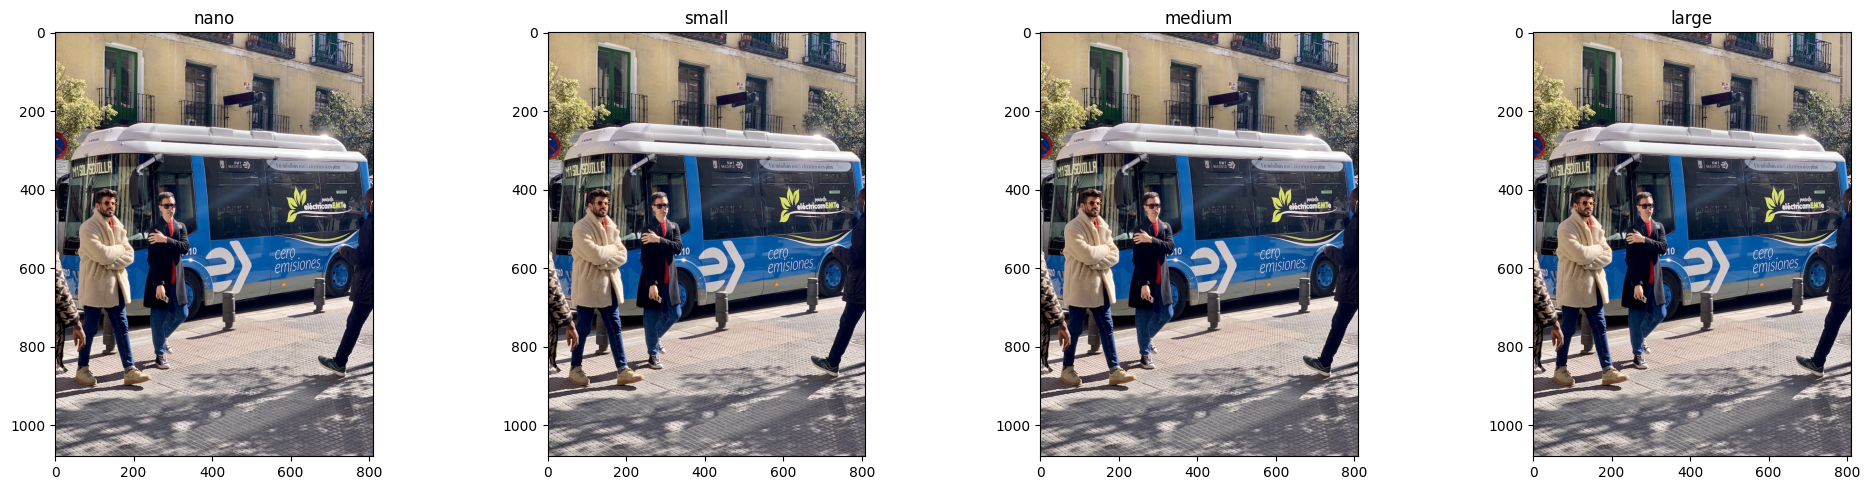

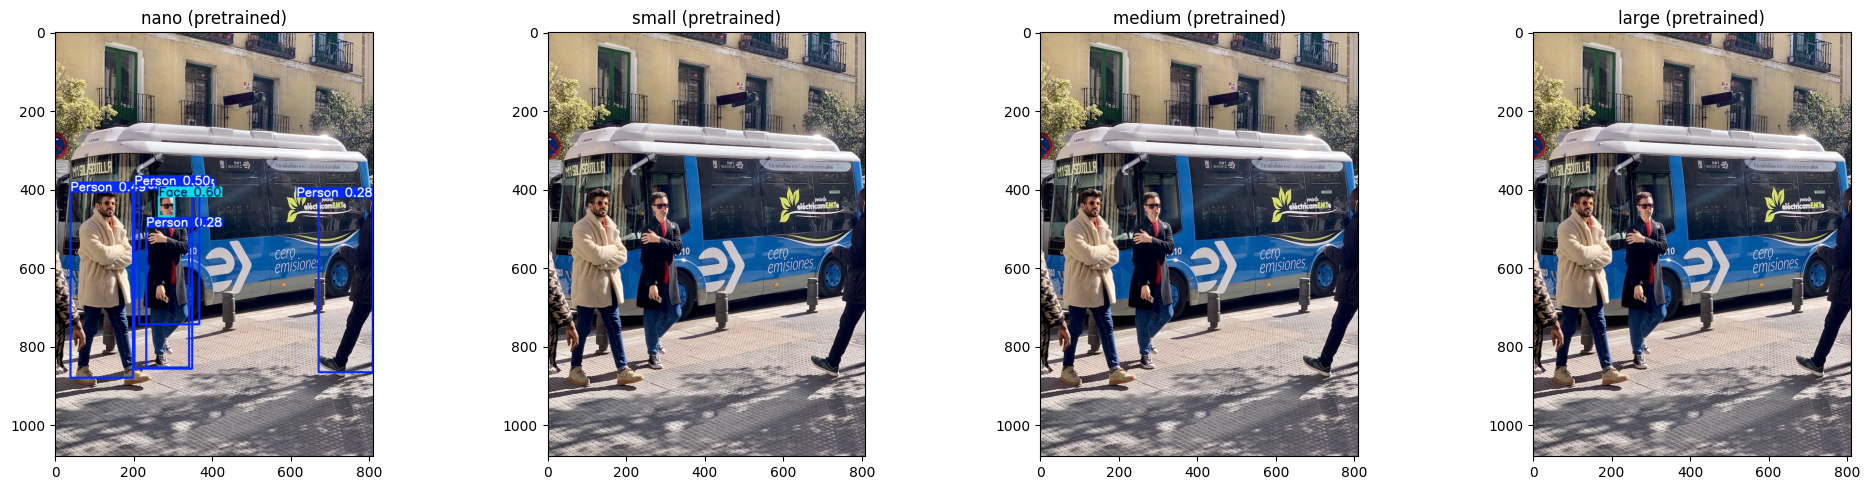

In [20]:
predict_many(
    ["train", "train2", "train3", "train4"], ["nano", "small", "medium", "large"]
)
predict_many(
    ["train7", "train8", "train9", "train10"],
    [
        "nano (pretrained)",
        "small (pretrained)",
        "medium (pretrained)",
        "large (pretrained)",
    ],
)

This one is interesting since the nano pre-trained model seems to do a better job and finding people than all others and I suspect this is because nano pre-trained here lost most of its pre-trained neurons since its so small, just to be replaced by the new ones, built specially for this task. The others I suspect were in the middle of this transition which is why they show nothing, much like the models without the pre-trained weights which of course show nothing.
